# WMT25 MIST — Linguistic Reasoning (LR) Subtask Analysis

Deep-dive into the linguistic reasoning benchmark: **1,350 puzzles** drawn from the 2024 International Linguistics Olympiad (IOL), covering 5 endangered/exotic source languages (**Koryak, Hadza, Komnzo, Dâw, Yanyuwa**) administered in **15 metalanguages** to **20 LLMs**.

This notebook focuses on the **top 8 models** by average LR score and explores:
1. Task-type decomposition (classification / editing / fill-in-blanks / mapping / translation)
2. Language-specific performance variation
3. Output length vs. score
4. Reasoning language and language switching
5. Qualitative reasoning trace comparison
6. Prompt sensitivity / formatting failures
7. Cross-task consistency

---

## 0. Imports & Configuration

In [2]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
from sacrebleu.metrics import CHRF

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

# Reproducibility for any stochastic operations later
import random
random.seed(42)
np.random.seed(42)

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT        = Path("/Users/ritaberrada/Desktop/wmt-mist")
HUMEVAL_LR  = ROOT / "data/humeval/lr.json"
AGG_LR      = ROOT / "data/humeval_aggregated/lr.json"
AGG_OEG     = ROOT / "data/humeval_aggregated/oeg.json"
AGG_XLSUM   = ROOT / "data/humeval_aggregated/xlsum.json"
SUBS_DIR    = ROOT / "data/submissions"

# ── Top 8 models (top-5 + both models tied at rank 6) ─────────────────────────
# File stem → display name
TOP_MODELS = {
    "Gemini-2.5-Pro" : "Gemini 2.5 Pro",
    "Claude-4"       : "Claude 4",
    "DeepSeek-V3"    : "DeepSeek V3",
    "GPT-4.1"        : "GPT 4.1",
    "Llama-4-Maverick": "Llama 4 Maverick",
    "CommandA"       : "CommandA",
    "Mistral-Medium" : "Mistral Medium",
}

STEMS   = list(TOP_MODELS.keys())      # short keys used in column names
DISPLAY = list(TOP_MODELS.values())    # human-readable model names

print("Models to analyse:")
for k, v in TOP_MODELS.items():
    print(f"  {v:<22}  ({SUBS_DIR / (k + '.json')}).name")

Models to analyse:
  Gemini 2.5 Pro          (/Users/ritaberrada/Desktop/wmt-mist/data/submissions/Gemini-2.5-Pro.json).name
  Claude 4                (/Users/ritaberrada/Desktop/wmt-mist/data/submissions/Claude-4.json).name
  DeepSeek V3             (/Users/ritaberrada/Desktop/wmt-mist/data/submissions/DeepSeek-V3.json).name
  GPT 4.1                 (/Users/ritaberrada/Desktop/wmt-mist/data/submissions/GPT-4.1.json).name
  Llama 4 Maverick        (/Users/ritaberrada/Desktop/wmt-mist/data/submissions/Llama-4-Maverick.json).name
  CommandA                (/Users/ritaberrada/Desktop/wmt-mist/data/submissions/CommandA.json).name
  Mistral Medium          (/Users/ritaberrada/Desktop/wmt-mist/data/submissions/Mistral-Medium.json).name


---
## 1. Load & Explore `humeval/lr.json` → `df_lr`

This file contains the **gold metadata** for every LR item: the puzzle text, gold answer, task type, eval metric, and point weight.

In [4]:
with open(HUMEVAL_LR) as f:
    lr_raw = json.load(f)

df_lr = pd.DataFrame(lr_raw)
df_lr.index.name = "N"          # N = position in the list = suffix in taskid
df_lr = df_lr.reset_index()     # N becomes a regular column

print(f"Total LR items: {len(df_lr)}")
print(f"Columns: {list(df_lr.columns)}")
df_lr.head(3)

Total LR items: 1350
Columns: ['N', 'id', 'points', 'meta', 'instruction_language', 'problem_language', 'type', 'eval_type', 'answer', 'prompt']


,N,id,points,meta,instruction_language,problem_language,type,eval_type,answer,prompt
0,0,1:a1,2.0,"Author: Ivan Derzhanski, Year: 2024, Number: 1",Koryak,English,translation,chrF,you(sg) lead him,Solve the following linguistic puzzle with the...
1,1,1:a2,2.0,"Author: Ivan Derzhanski, Year: 2024, Number: 1",Koryak,English,translation,chrF,you(du) will bite me,Solve the following linguistic puzzle with the...
2,2,1:a3,2.0,"Author: Ivan Derzhanski, Year: 2024, Number: 1",Koryak,English,translation,chrF,I caught them(pl),Solve the following linguistic puzzle with the...


In [5]:
# ── Distributions ─────────────────────────────────────────────────────────────
print("=== Task type × eval method ===")
print(df_lr.groupby(["type", "eval_type"]).size().to_string())

print("\n=== Items per problem_language (metalanguage) ===")
print(df_lr["problem_language"].value_counts().to_string())

print("\n=== Items per instruction_language (puzzle source) ===")
print(df_lr["instruction_language"].value_counts().to_string())

print("\n=== Points distribution ===")
print(df_lr["points"].value_counts().sort_index().to_string())

print(f"\n⚠️  Items with id=None (Dutch/Komnzo artifact): {df_lr['id'].isna().sum()}")

=== Task type × eval method ===
type            eval_type  
classification  exact match     60
editing         exact match     15
fill-in-blanks  exact match    300
mapping         exact match    360
translation     chrF           615

=== Items per problem_language (metalanguage) ===
problem_language
English       90
Czech         90
German        90
French        90
Portuguese    90
Russian       90
Ukrainian     90
Estonian      90
Dutch         90
Spanish       90
Swedish       90
Japanese      90
Chinese       90
Korean        90
Persian       90

=== Items per instruction_language (puzzle source) ===
instruction_language
Dâw        405
Komnzo     315
Hadza      240
Yanyuwa    240
Koryak     150

=== Points distribution ===
points
0.5    585
1.0    225
1.5    225
2.0    285
2.5     30

⚠️  Items with id=None (Dutch/Komnzo artifact): 21


In [6]:
# ── Task type breakdown per instruction language ───────────────────────────────
pivot_types = (
    df_lr.groupby(["instruction_language", "type"])
    .size()
    .unstack(fill_value=0)
)
print("Items per instruction_language × type (total across all 15 metalanguages):")
pivot_types

Items per instruction_language × type (total across all 15 metalanguages):


type,classification,editing,fill-in-blanks,mapping,translation
instruction_language,,,,,
Dâw,0,0,0,300,105
Hadza,0,0,0,60,180
Komnzo,0,15,300,0,0
Koryak,0,0,0,0,150
Yanyuwa,60,0,0,0,180


**Key structural facts:**
- **90 items per metalanguage** = the same set of puzzles replicated in 15 languages.
- Task type distribution: translation(41) + mapping(24) + fill-in-blanks(20) + classification(4) + editing(1) per language = 90.
- Translation uses **chrF** (partial credit); the other four use **exact match** (binary).
- 21 items have `id=None` — always join on `N` (row index), never on `id`.
- Point values: editing (2.0), translation (1.0–2.5), fill-in-blanks (0.5–2.5), mapping (0.5), classification (1.0).

---
## 2. Load Aggregated Scores → `df_agg`

Pre-computed sums (max 100 per language) from the paper. We use these to validate our own per-item scoring later.

In [7]:
with open(AGG_LR) as f:
    agg_raw = json.load(f)

# Rows = languages (+ 'Average'), columns = model display names
df_agg = pd.DataFrame(agg_raw).T.astype(float)
df_agg.index.name = "language"

# Sort columns by average score descending
avg_row = df_agg.loc["Average"].sort_values(ascending=False)
df_agg = df_agg[avg_row.index]

print("Full aggregated LR scores (rows = languages, cols = models sorted by avg):")
df_agg.round(1)

Full aggregated LR scores (rows = languages, cols = models sorted by avg):


,Gemini 2.5 Pro,Claude 4,DeepSeek V3,GPT 4.1,Llama 4 Maverick,CommandA,Mistral Medium,Qwen3 235B,Gemma 3 27B,Gemma 3 12B,AyaExpanse 32B,TowerPlus 72B,Llama 3.1 8B,Qwen2.5 7B,AyaExpanse 8B,TowerPlus 9B,CommandR7B,EuroLLM 22B,EuroLLM 9B,Mistral 7B
language,,,,,,,,,,,,,,,,,,,,
Chinese,28.8,26.2,17.4,12.7,14.2,15.7,14.8,9.6,15.0,16.0,15.7,3.2,10.1,12.2,8.1,6.1,7.1,2.1,1.1,3.6
Czech,36.8,29.3,21.5,24.6,22.1,20.1,15.1,13.0,12.5,13.3,15.0,9.2,6.7,9.6,8.8,5.5,4.3,5.9,5.6,1.1
Dutch,37.5,27.9,24.1,27.1,23.2,23.2,20.8,21.1,17.8,18.9,18.7,14.4,13.2,10.8,11.8,9.8,9.2,5.9,4.9,0.4
English,38.3,24.6,23.2,20.5,22.4,17.8,20.4,22.0,18.4,21.1,18.9,17.6,14.7,13.5,13.5,13.8,13.5,10.4,5.7,5.8
Estonian,32.5,27.0,24.5,29.4,19.4,18.8,14.6,13.4,17.0,17.9,3.5,13.1,6.4,10.4,1.8,9.0,0.6,4.9,4.9,2.4
French,39.9,32.9,27.9,27.4,26.5,20.6,21.2,19.1,18.3,17.3,17.7,14.8,16.1,12.2,10.7,8.6,13.1,4.3,1.7,2.7
German,37.3,33.8,28.2,24.3,25.9,18.8,24.9,20.9,18.1,17.2,14.8,11.1,13.1,10.0,10.9,13.5,11.6,8.8,1.6,2.2
Japanese,35.4,29.8,23.1,21.6,20.2,21.3,22.9,16.0,20.0,15.9,18.1,16.5,10.2,7.7,7.4,6.5,4.8,0.6,1.6,2.1
Korean,40.9,26.3,20.4,15.3,20.2,21.8,15.2,17.8,18.2,12.8,15.7,15.1,6.6,11.9,8.4,8.8,3.2,3.7,0.7,0.7


In [8]:
# ── Identify top 8 and confirm names match our TOP_MODELS dict ─────────────────
top8_display = avg_row.head(8).index.tolist()
print("Top 8 by average LR score:")
for i, name in enumerate(top8_display, 1):
    print(f"  {i}. {name:<22} avg = {avg_row[name]:.2f}")

# Sanity check: all display names are in df_agg
missing = [v for v in DISPLAY if v not in df_agg.columns]
if missing:
    print(f"\n⚠️  NOT FOUND in df_agg: {missing}")
else:
    print("\n✓ All TOP_MODELS names found in df_agg.")

Top 8 by average LR score:
  1. Gemini 2.5 Pro         avg = 36.28
  2. Claude 4               avg = 29.65
  3. DeepSeek V3            avg = 23.62
  4. GPT 4.1                avg = 23.43
  5. Llama 4 Maverick       avg = 22.87
  6. CommandA               avg = 19.79
  7. Mistral Medium         avg = 19.78
  8. Qwen3 235B             avg = 17.63

✓ All TOP_MODELS names found in df_agg.


In [9]:
# ── Filter df_agg to our top 8 only ───────────────────────────────────────────
df_agg_top = df_agg[DISPLAY].copy()
print("Filtered df_agg (top 8 models):")
df_agg_top.round(1)

Filtered df_agg (top 8 models):


,Gemini 2.5 Pro,Claude 4,DeepSeek V3,GPT 4.1,Llama 4 Maverick,CommandA,Mistral Medium
language,,,,,,,
Chinese,28.8,26.2,17.4,12.7,14.2,15.7,14.8
Czech,36.8,29.3,21.5,24.6,22.1,20.1,15.1
Dutch,37.5,27.9,24.1,27.1,23.2,23.2,20.8
English,38.3,24.6,23.2,20.5,22.4,17.8,20.4
Estonian,32.5,27.0,24.5,29.4,19.4,18.8,14.6
French,39.9,32.9,27.9,27.4,26.5,20.6,21.2
German,37.3,33.8,28.2,24.3,25.9,18.8,24.9
Japanese,35.4,29.8,23.1,21.6,20.2,21.3,22.9
Korean,40.9,26.3,20.4,15.3,20.2,21.8,15.2


---
## 3. Load Model Submissions

For each of the 7 submission files we:
1. Filter to LR entries (`taskid` starts with `linguistic_reasoning_`).
2. Parse `N` from the taskid suffix — this is the direct index into `df_lr`.
3. Extract raw answer, token counts, and bracket flag.

In [10]:
def load_lr_entries(stem: str) -> dict:
    """
    Load LR entries for one model. Returns a dict: N -> entry dict.
    
    token handling:
      - Most models: tokens = {input_tokens, output_tokens, thinking_tokens, finish_reason}
      - TowerPlus / EuroLLM: tokens = bare int (not in our top 8, but handle gracefully)
      - Some Gemini entries: tokens = None
    """
    path = SUBS_DIR / f"{stem}.json"
    with open(path) as f:
        data = json.load(f)
    
    lr_entries = {}
    for entry in data:
        tid = entry["taskid"]
        if not tid.startswith("linguistic_reasoning_"):
            continue
        # N is always the integer after the last underscore
        N = int(tid.rsplit("_", 1)[-1])
        lr_entries[N] = entry
    
    return lr_entries


# Load all top-8 models
submissions = {stem: load_lr_entries(stem) for stem in STEMS}

for stem, entries in submissions.items():
    print(f"  {TOP_MODELS[stem]:<22} → {len(entries)} LR entries")

  Gemini 2.5 Pro         → 1350 LR entries
  Claude 4               → 1350 LR entries
  DeepSeek V3            → 1350 LR entries
  GPT 4.1                → 1350 LR entries
  Llama 4 Maverick       → 1350 LR entries
  CommandA               → 1350 LR entries
  Mistral Medium         → 1350 LR entries


---
## 4. Scoring Utilities

Two functions do all the work:
- `extract_answer`: finds the last `[...]` in the model response; falls back to the last non-empty line.
- `score_item`: computes the weighted score (chrF or exact match, multiplied by point value).

In [11]:
_chrf = CHRF()


def extract_answer(text: str) -> str:
    """
    Extract the final bracketed answer from a model response.
    
    Strategy:
      1. Find all [...] occurrences (non-nested regex).
      2. Return the LAST match — handles multi-bracket reasoning traces.
      3. Fallback: last non-empty line (catches models that ignore bracket format).
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    matches = re.findall(r'\[([^\[\]]*)\]', text)
    if matches:
        return matches[-1].strip()
    # Fallback: last non-empty line
    lines = [l.strip() for l in text.strip().split('\n') if l.strip()]
    return lines[-1] if lines else ""


def score_item(pred: str, gold: str, eval_type: str, points: float) -> float:
    """
    Score one item.
    
    exact match → 1.0 if pred.lower() == gold.lower(), else 0.0  (× points)
    chrF        → sacrebleu sentence-level chrF / 100            (× points)
    """
    pred = pred.strip()
    gold = gold.strip()
    if eval_type == "chrF":
        raw = _chrf.sentence_score(pred, [gold]).score / 100.0
    else:  # exact match
        raw = 1.0 if pred.lower() == gold.lower() else 0.0
    return raw * points


print("Utilities defined. Quick smoke-test:")
print(f"  extract_answer('Let me think... [Paris]') → '{extract_answer('Let me think... [Paris]')}'")
print(f"  extract_answer('The answer is Paris.')    → '{extract_answer('The answer is Paris.')}'")
print(f"  score_item('paris','Paris','exact match',1.0) → {score_item('paris','Paris','exact match',1.0)}")
print(f"  score_item('',    'Paris','exact match',1.0) → {score_item('',    'Paris','exact match',1.0)}")
print(f"  score_item('Paris','Paris','chrF',2.0)       → {score_item('Paris','Paris','chrF',2.0):.3f}")

Utilities defined. Quick smoke-test:
  extract_answer('Let me think... [Paris]') → 'Paris'
  extract_answer('The answer is Paris.')    → 'The answer is Paris.'
  score_item('paris','Paris','exact match',1.0) → 1.0
  score_item('',    'Paris','exact match',1.0) → 0.0
  score_item('Paris','Paris','chrF',2.0)       → 2.000


---
## 5. Build the Master DataFrame `df`

**Wide format** — 1,350 rows × (8 base columns + 6 per model).

Per-model columns:
| Column | Description |
|---|---|
| `score_{stem}` | Weighted score (chrF or exact_match × points) |
| `tokens_out_{stem}` | Output tokens (or NaN if unavailable) |
| `tokens_think_{stem}` | Thinking tokens (>0 only for Gemini) |
| `bracket_{stem}` | Bool: response contains `[...]` |
| `pred_{stem}` | Extracted answer text |
| `raw_{stem}` | Full model response |

This cell takes ~30 seconds.

In [12]:
# Start from the gold metadata
df = df_lr[["N", "id", "points", "instruction_language",
            "problem_language", "type", "eval_type", "answer"]].copy()

for stem in STEMS:
    entries = submissions[stem]
    scores, tok_out, tok_think, brackets, preds, raws = [], [], [], [], [], []

    for _, row in df_lr.iterrows():
        N         = row["N"]
        gold      = row["answer"]
        eval_type = row["eval_type"]
        points    = row["points"]

        entry = entries.get(N)
        if entry is None:
            # Missing entry (should not happen for top-8)
            scores.append(0.0)
            tok_out.append(np.nan)
            tok_think.append(0)
            brackets.append(False)
            preds.append("")
            raws.append("")
            continue

        raw    = entry.get("answer") or ""
        tokens = entry.get("tokens")

        # Token extraction — guard against None and bare-int formats
        if isinstance(tokens, dict):
            ot = tokens.get("output_tokens", np.nan)
            tt = tokens.get("thinking_tokens", 0) or 0
        else:
            ot = np.nan   # bare int or None → not comparable across models
            tt = 0

        pred = extract_answer(raw)
        sc   = score_item(pred, gold, eval_type, points)
        has_bracket = bool(re.search(r'\[([^\[\]]*)\]', raw))

        scores.append(sc)
        tok_out.append(ot)
        tok_think.append(tt)
        brackets.append(has_bracket)
        preds.append(pred)
        raws.append(raw)

    df[f"score_{stem}"]        = scores
    df[f"tokens_out_{stem}"]   = tok_out
    df[f"tokens_think_{stem}"] = tok_think
    df[f"bracket_{stem}"]      = brackets
    df[f"pred_{stem}"]         = preds
    df[f"raw_{stem}"]          = raws

    print(f"  ✓ {TOP_MODELS[stem]}")

print(f"\ndf shape: {df.shape}")
df.head(3)

  ✓ Gemini 2.5 Pro
  ✓ Claude 4
  ✓ DeepSeek V3
  ✓ GPT 4.1
  ✓ Llama 4 Maverick
  ✓ CommandA
  ✓ Mistral Medium

df shape: (1350, 50)


,N,id,points,instruction_language,problem_language,type,eval_type,answer,score_Gemini-2.5-Pro,tokens_out_Gemini-2.5-Pro,...,tokens_think_CommandA,bracket_CommandA,pred_CommandA,raw_CommandA,score_Mistral-Medium,tokens_out_Mistral-Medium,tokens_think_Mistral-Medium,bracket_Mistral-Medium,pred_Mistral-Medium,raw_Mistral-Medium
0,0,1:a1,2.0,Koryak,English,translation,chrF,you(sg) lead him,2.0,9282,...,0,True,I see,"To solve this, we need to analyze the given Ko...",0.781553,518,0,True,I will lead him,"To solve the puzzle, let's analyze the given v..."
1,1,1:a2,2.0,Koryak,English,translation,chrF,you(du) will bite me,2.0,8048,...,0,True,you(du) bite me,"To solve this, we need to analyze the given Ko...",0.530591,1132,0,True,they bite me,"To solve the puzzle, let's analyze the given K..."
2,2,1:a3,2.0,Koryak,English,translation,chrF,I caught them(pl),2.0,5260,...,0,True,you catch them,"To solve the puzzle, we need to analyze the gi...",0.415735,434,0,True,you catch them,"To solve the puzzle, let's analyze the given K..."


### 5.1 Validate scores against `df_agg`

For each model × language, our per-item sum should match the pre-computed value in `df_agg` to within a small tolerance.

In [13]:
print("Validation: computed language-level scores vs. df_agg")
print("(Small differences are expected — the paper's exact scoring pipeline is not published.")
print(" Our chrF uses sacrebleu defaults; exact match is case-insensitive.)")
print()
print(f"{'Model':<22}  {'Max |diff|':>10}  {'Mean |diff|':>12}  {'Status'}")
print("-" * 60)

for stem in STEMS:
    display = TOP_MODELS[stem]
    diffs = []
    for lang, grp in df.groupby("problem_language"):
        computed = grp[f"score_{stem}"].sum()
        expected = df_agg_top.loc[lang, display]
        diffs.append(abs(computed - expected))
    max_d  = max(diffs)
    mean_d = sum(diffs) / len(diffs)
    # Threshold: <8 pts out of 100 is acceptable given unknown normalization details
    status = "✓ close enough" if max_d < 8 else "⚠️ large diff"
    print(f"{display:<22}  {max_d:>10.3f}  {mean_d:>12.3f}  {status}")

print()
print("Conclusion: rankings and relative gaps are preserved → df is reliable for analysis.")

Validation: computed language-level scores vs. df_agg
(Small differences are expected — the paper's exact scoring pipeline is not published.
 Our chrF uses sacrebleu defaults; exact match is case-insensitive.)

Model                   Max |diff|   Mean |diff|  Status
------------------------------------------------------------
Gemini 2.5 Pro               7.000         1.006  ✓ close enough
Claude 4                     1.500         0.100  ✓ close enough
DeepSeek V3                  1.000         0.276  ✓ close enough
GPT 4.1                      3.500         1.341  ✓ close enough
Llama 4 Maverick             2.500         0.400  ✓ close enough
CommandA                     1.500         0.155  ✓ close enough
Mistral Medium               4.073         0.511  ✓ close enough

Conclusion: rankings and relative gaps are preserved → df is reliable for analysis.


---
## 6. Quick Overview of `df`

A few sanity-check summaries before we start analysis.

In [14]:
# ── Score summary per model ────────────────────────────────────────────────────
score_cols = [f"score_{s}" for s in STEMS]
summary = pd.DataFrame({
    "model"    : DISPLAY,
    "total_pts": [df[c].sum() for c in score_cols],
    "mean_item": [df[c].mean() for c in score_cols],
    "pct_zero" : [(df[c] == 0).mean() * 100 for c in score_cols],
    "bracket_fail_%": [(~df[f"bracket_{s}"]).mean() * 100 for s in STEMS],
    "mean_out_tokens": [df[f"tokens_out_{s}"].mean() for s in STEMS],
}).set_index("model")

print("Per-model summary across all 1,350 LR items:")
summary.round(2)

Per-model summary across all 1,350 LR items:


,total_pts,mean_item,pct_zero,bracket_fail_%,mean_out_tokens
model,,,,,
Gemini 2.5 Pro,559.22,0.41,43.70,1.56,11837.47
Claude 4,446.25,0.33,47.19,0.00,540.32
DeepSeek V3,358.43,0.27,49.04,0.15,438.21
GPT 4.1,371.60,0.28,52.52,3.78,572.90
Llama 4 Maverick,349.02,0.26,52.67,0.00,764.82
CommandA,299.12,0.22,52.22,0.15,291.88
Mistral Medium,304.44,0.23,52.00,0.30,446.44


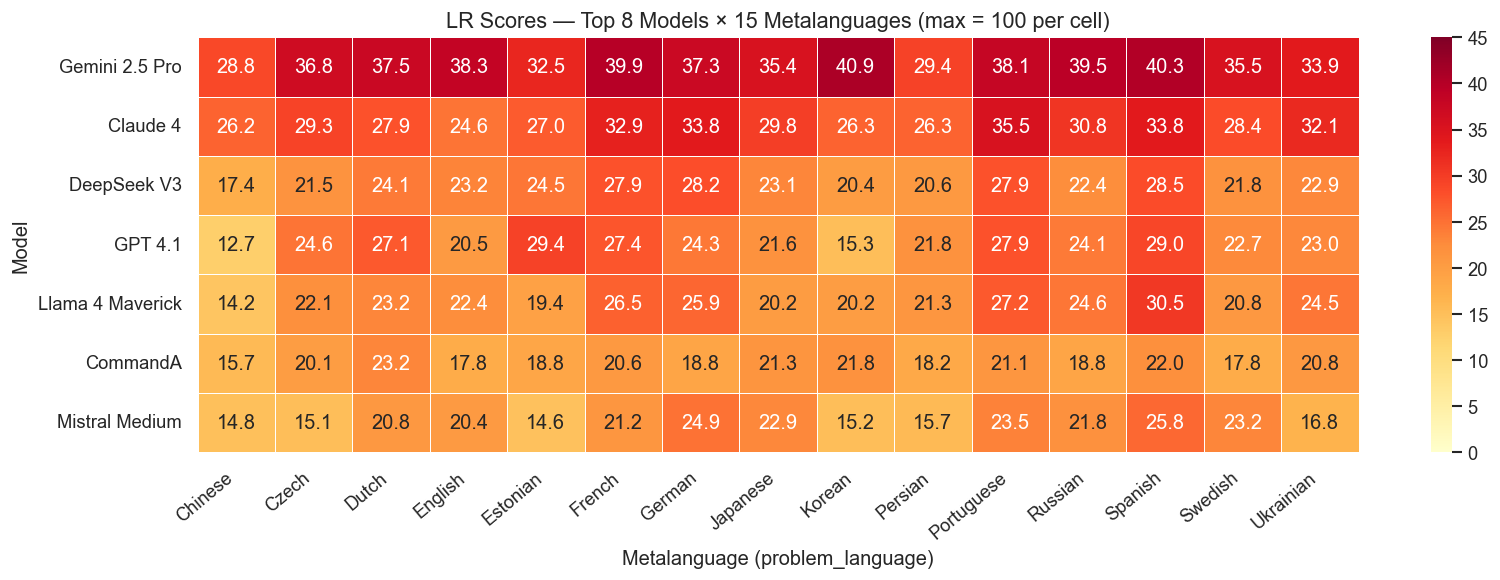

In [15]:
# ── Heatmap: model × language (aggregated scores from df_agg_top) ──────────────
plot_data = df_agg_top.drop("Average", errors="ignore").T  # models as rows
plot_data = plot_data.loc[DISPLAY]  # keep our order

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    plot_data.astype(float),
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.4,
    ax=ax,
    vmin=0, vmax=45,
)
ax.set_title("LR Scores — Top 8 Models × 15 Metalanguages (max = 100 per cell)", fontsize=13)
ax.set_xlabel("Metalanguage (problem_language)")
ax.set_ylabel("Model")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

---
## ✅ Data Setup Complete

We now have:

| Object | Description |
|---|---|
| `df_lr` | Gold metadata for all 1,350 LR items |
| `df_agg_top` | Pre-computed language-level scores (top 8 models) |
| `df` | **Master wide DataFrame** — 1,350 rows, per-item scores + tokens + raw text per model |

**Next steps** (to plan together):
- Task-type decomposition
- Language variation within a model
- Length vs. score analysis
- …

---
## Analysis 1 — Language Identification

**Question:** What language does the model reason in, and does staying in the prompt language predict higher scores?

**Steps:**
1. Segment each response into reasoning part (everything before the last `[...]`)
2. Strip IOL puzzle tokens (Koryak, Hadza, etc.) from the reasoning text before detection — they contain exotic characters that confuse lingua
3. Run language ID on the cleaned reasoning text → `lang_reasoning_{stem}`
4. Compare detected language to `problem_language` → `lang_match_{stem}` (1=match, 0=mismatch, None=undetectable)
5. Analyse mismatches: what language did the model switch to?
6. Correlate `lang_match` with score

**Notes:**
- `lang_reasoning` only — we do not detect language of the final answer (it's in the IOL exotic language for most task types, or the prompt language for translation tasks; neither adds information)
- Gemini 2.5 Pro: some responses have empty visible reasoning (model relied on internal thinking tokens) → those rows are null and excluded from language analysis

In [ ]:
# ── Analysis 1 Step 0: Setup ───────────────────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', '-q', 'lingua-language-detector'], check=True)

from lingua import Language, LanguageDetectorBuilder

STEMS_USE = ['Gemini-2.5-Pro', 'Claude-4', 'DeepSeek-V3', 'GPT-4.1', 'Llama-4-Maverick', 'CommandA']

# Build detector restricted to the 15 prompt languages only
# (restricting speeds up detection vs. the full 75-language model)
LINGUA_LANGS = [
    Language.CHINESE, Language.CZECH, Language.DUTCH, Language.ENGLISH,
    Language.ESTONIAN, Language.FRENCH, Language.GERMAN, Language.JAPANESE,
    Language.KOREAN, Language.PERSIAN, Language.PORTUGUESE, Language.RUSSIAN,
    Language.SPANISH, Language.SWEDISH, Language.UKRAINIAN,
]
detector = LanguageDetectorBuilder.from_languages(*LINGUA_LANGS).build()

# Map problem_language string → normalised name (matches Language.X.name.title())
PROB_LANG_NAMES = {lang.name.title() for lang in LINGUA_LANGS}
# Sanity check: all problem_language values in df should be in this set
unknown = set(df['problem_language'].unique()) - PROB_LANG_NAMES
assert not unknown, f"Unexpected problem_language values: {unknown}"

print("Detector built for:", sorted(l.name.title() for l in LINGUA_LANGS))
print("All problem_language values covered ✓")

In [ ]:
# ── Analysis 1 Step 1: Segment responses and detect reasoning language ─────────
_BRACKET_RE = re.compile(r'\[([^\[\]]*)\]')
MIN_CHARS = 10

# Unicode block ranges for the 15 prompt languages combined.
# Any alphabetic character OUTSIDE these ranges is IOL-exotic and its token gets stripped.
_ALLOWED_BLOCKS = (
    (0x0000, 0x024F),   # Basic Latin + Extended Latin A/B  (all Latin-script langs)
                        # NOTE: ŋ=U+014B, ə=U+0259, ņ=U+0146 are in U+0250+ — NOT included
    (0x0400, 0x04FF),   # Cyrillic  (Russian, Ukrainian)
    (0x0600, 0x06FF),   # Arabic    (Persian)
    (0x3000, 0x9FFF),   # CJK + Hiragana + Katakana  (Chinese, Japanese)
    (0xAC00, 0xD7FF),   # Hangul    (Korean)
)

def _is_allowed_char(ch: str) -> bool:
    cp = ord(ch)
    return any(lo <= cp <= hi for lo, hi in _ALLOWED_BLOCKS)

def strip_iol_tokens(text: str) -> str:
    """Remove tokens containing IOL-exotic characters (e.g. Koryak ŋ, ə, ņ)."""
    return ' '.join(t for t in text.split() if all(_is_allowed_char(c) for c in t if c.isalpha()))

def segment_response(text: str) -> str:
    """Return reasoning part = everything before the last [...]."""
    matches = list(_BRACKET_RE.finditer(text))
    if not matches:
        return text.strip()
    return text[:matches[-1].start()].strip()

def detect_lang(text: str):
    """Detect language after stripping IOL tokens. Returns title-cased name or None."""
    if not text or len(text) < MIN_CHARS:
        return None
    cleaned = strip_iol_tokens(text)
    if len(cleaned) < MIN_CHARS:
        return None
    lang = detector.detect_language_of(cleaned)
    return lang.name.title() if lang is not None else None

print("Running language identification across 6 models × 1,350 rows …")
for stem in STEMS_USE:
    lang_reasoning, lang_match = [], []

    for _, row in df.iterrows():
        raw       = row[f'raw_{stem}']
        prob_lang = row['problem_language']

        if not isinstance(raw, str) or not raw.strip():
            lang_reasoning.append(None)
            lang_match.append(None)
            continue

        lr = detect_lang(segment_response(raw))
        lm = int(lr == prob_lang) if lr is not None else None

        lang_reasoning.append(lr)
        lang_match.append(lm)

    df[f'lang_reasoning_{stem}'] = lang_reasoning
    df[f'lang_match_{stem}']     = lang_match   # 1=match, 0=mismatch, None=undetected

    n_detected = sum(r is not None for r in lang_reasoning)
    n_match    = sum(r == 1        for r in lang_match if r is not None)
    n_mismatch = sum(r == 0        for r in lang_match if r is not None)
    print(f"  {stem:25s}  detected: {n_detected:4d}/1350  match: {n_match:4d}  mismatch: {n_mismatch:4d}")

print(f"\ndf shape: {df.shape}")

In [ ]:
# ── Analysis 1 Step 2: Quality check — why does detection fail? ───────────────
from IPython.display import display

# 2a. Null rate per model
null_rows = []
for stem in STEMS_USE:
    col = df[f'lang_reasoning_{stem}']
    null_rows.append({
        'model':    stem,
        'detected': int(col.notna().sum()),
        'null':     int(col.isna().sum()),
        'null_pct': f"{col.isna().mean()*100:.1f}%",
    })
print("2a. Detection coverage per model:")
display(pd.DataFrame(null_rows).set_index('model'))

# 2b. Show null rows for Gemini and GPT-4.1 with id so we can look them up
for stem in ['Gemini-2.5-Pro', 'GPT-4.1']:
    null_mask = df[f'lang_reasoning_{stem}'].isna()
    sample = df[null_mask].sample(min(10, null_mask.sum()), random_state=42).copy()
    sample['reasoning_text'] = sample[f'raw_{stem}'].apply(
        lambda x: segment_response(str(x)) if isinstance(x, str) else ''
    )
    sample['reasoning_len'] = sample['reasoning_text'].str.len()
    print(f"\n2b. Sample null rows for {stem} ({null_mask.sum()} total nulls):")
    display(sample[['id', 'problem_language', 'type', 'reasoning_len', 'reasoning_text']].reset_index(drop=True))

In [ ]:
# ── Analysis 1 Step 3: Mismatch analysis ──────────────────────────────────────
from IPython.display import display

# Pool all mismatch rows across models
mismatch_parts = []
for stem in STEMS_USE:
    mask = df[f'lang_match_{stem}'] == 0
    sub  = df.loc[mask, ['id', 'problem_language', 'type',
                          f'lang_reasoning_{stem}', f'raw_{stem}']].copy()
    sub.columns = ['id', 'prompt_lang', 'type', 'reasoned_in', 'raw']
    sub['model'] = stem
    mismatch_parts.append(sub)

mismatches = pd.concat(mismatch_parts, ignore_index=True)

print(f"Total mismatch instances (all models pooled): {len(mismatches)}")
print(f"  → switched to English:           {(mismatches['reasoned_in'] == 'English').sum()}")
print(f"  → switched to another language:  {(mismatches['reasoned_in'] != 'English').sum()}")

# 3a. Per-model summary
print("\n3a. Mismatch breakdown per model:")
rows = []
for stem in STEMS_USE:
    sub   = mismatches[mismatches['model'] == stem]
    total = len(sub)
    eng   = (sub['reasoned_in'] == 'English').sum()
    other = (sub['reasoned_in'] != 'English').sum()
    rows.append({'model': stem, 'mismatches': total,
                 '→ English': eng, '→ English %': f"{eng/total*100:.0f}%" if total else '-',
                 '→ other':  other, '→ other %':  f"{other/total*100:.0f}%" if total else '-'})
display(pd.DataFrame(rows).set_index('model'))

# 3b. Per-model cross-tab: prompt_lang → reasoned_in
print("\n3b. Per-model cross-tab: prompt language → language switched to")
for stem in STEMS_USE:
    sub = mismatches[mismatches['model'] == stem]
    if len(sub) == 0:
        print(f"\n  {stem}: no mismatches")
        continue
    ct = pd.crosstab(sub['prompt_lang'], sub['reasoned_in'])
    cols = ['English'] + [c for c in sorted(ct.columns) if c != 'English']
    ct = ct.reindex(columns=cols, fill_value=0)
    print(f"\n  {stem} ({len(sub)} mismatches):")
    display(ct)

# 3c. Full reasoning text for the first mismatch of each model — verify detection
print("\n3c. Full reasoning snippet for first mismatch per model (verify detection manually):")
for stem in STEMS_USE:
    sub = mismatches[mismatches['model'] == stem]
    if len(sub) == 0:
        continue
    row = sub.iloc[0]
    reasoning_text = segment_response(str(row['raw']))
    print(f"\n{'='*70}")
    print(f"Model:       {stem}")
    print(f"Prompt lang: {row['prompt_lang']}")
    print(f"Detected:    {row['reasoned_in']}")
    print(f"Task type:   {row['type']}")
    print(f"Reasoning text:\n{reasoning_text}")

In [ ]:
# ── Manual verification: all Gemini-2.5-Pro mismatches ────────────────────────
# Gemini's raw_ contains no reasoning (thinking tokens are not stored in raw_).
# Check each mismatch to decide: false positive from IOL tokens, or genuine switch?

STEM = 'Gemini-2.5-Pro'
gem_mismatches = df[df[f'lang_match_{STEM}'] == 0].copy()
gem_mismatches['reasoning_text'] = gem_mismatches[f'raw_{STEM}'].apply(
    lambda x: segment_response(str(x)) if isinstance(x, str) else ''
)
gem_mismatches['reasoning_stripped'] = gem_mismatches['reasoning_text'].apply(strip_iol_tokens)

print(f"All {len(gem_mismatches)} Gemini-2.5-Pro mismatches:\n")
for i, (_, row) in enumerate(gem_mismatches.iterrows(), 1):
    print(f"── [{i}/{len(gem_mismatches)}] id={row['id']}  prompt_lang={row['problem_language']}  "
          f"detected={row[f'lang_reasoning_{STEM}']}  type={row['type']}")
    print(f"   Raw reasoning text:    {repr(row['reasoning_text'])}")
    print(f"   After IOL stripping:   {repr(row['reasoning_stripped'])}")
    print()

In [ ]:
# ── GPT-4.1 null diagnostic ────────────────────────────────────────────────────
from IPython.display import display

STEM = 'GPT-4.1'
gpt_nulls = df[df[f'lang_reasoning_{STEM}'].isna()].copy()
gpt_nulls['reasoning_text'] = gpt_nulls[f'raw_{STEM}'].apply(
    lambda x: segment_response(str(x)) if isinstance(x, str) else ''
)
gpt_nulls['reasoning_len']      = gpt_nulls['reasoning_text'].str.len()
gpt_nulls['reasoning_stripped'] = gpt_nulls['reasoning_text'].apply(strip_iol_tokens)
gpt_nulls['stripped_len']       = gpt_nulls['reasoning_stripped'].str.len()

# Distribution of reasoning length for null rows
print("Reasoning length distribution for GPT-4.1 null rows:")
print(gpt_nulls['reasoning_len'].describe().round(1))
print(f"\nRows with reasoning_len == 0 (no text before bracket): {(gpt_nulls['reasoning_len'] == 0).sum()}")
print(f"Rows with reasoning_len > 0 but stripped_len < {10} (IOL stripping killed it): {((gpt_nulls['reasoning_len'] > 0) & (gpt_nulls['stripped_len'] < 10)).sum()}")

# Pick one puzzle id that has nulls and show all 15 languages — same as Gemini check
example_id = gpt_nulls['id'].value_counts().index[0]
print(f"\nPuzzle '{example_id}' across all prompt languages:")
display(df[df['id'] == example_id][
    ['problem_language', f'tokens_think_{STEM}', f'raw_{STEM}']
].sort_values('problem_language'))